This notebook has analysis, models after we change the position of sensor to shaft end with hypothesis of this might help capturing vibrations easily which inturn makes differentiating normal and unbalance state easy

In [ ]:
import zipfile
import os

zip_path = "/content/Data for modelling_v3.zip"
extract_path = "/content/extracted_data"

# Create directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List the extracted files to see what we're working with
extracted_files = os.listdir(extract_path)
print("Extracted files:", extracted_files)


Extracted files: ['Data for modelling']


### Phase 1, Step 1: Parsing the JSON structure
Here we load the `.jsonl` files into a pandas DataFrame. We also add a `machine_state` column derived from the filename so we keep track of the labels.

In [ ]:
import os
import json
import pandas as pd
import glob

data_dir = "/content/extracted_data/Data for modelling"
jsonl_files = glob.glob(os.path.join(data_dir, "*.jsonl"))

all_data = []

for file_path in jsonl_files:
    # Extract the state from the filename (e.g., 'Normal_state', 'Bearing_fault_state')
    filename = os.path.basename(file_path)
    state = filename.split('_2000rpm')[0].replace('_', ' ')

    with open(file_path, 'r') as f:
        for line in f:
            try:
                row_data = json.loads(line.strip())
                row_data['machine_state'] = state
                all_data.append(row_data)
            except json.JSONDecodeError:
                continue # Skip invalid lines if any

# Convert to a pandas DataFrame
df = pd.DataFrame(all_data)

print(f"Total rows loaded: {len(df)}")
display(df.head())


Total rows loaded: 11209


,time,axis,data,machine_state
0,1.774998e+09,Y,"[-139.55859375, -145.55859375, -163.55859375, ...",NormalState withOutScrews 10mins
1,1.774998e+09,Z,"[-84.328125, -92.328125, -79.328125, -89.32812...",NormalState withOutScrews 10mins
2,1.774998e+09,X,"[-57.8857421875, -57.8857421875, -57.885742187...",NormalState withOutScrews 10mins
3,1.774998e+09,Y,"[-138.15625, -124.15625, -128.15625, -129.1562...",NormalState withOutScrews 10mins
4,1.774998e+09,Z,"[-47.9267578125, 0.0732421875, 111.0732421875,...",NormalState withOutScrews 10mins


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11209 entries, 0 to 11208
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           11209 non-null  float64
 1   axis           11209 non-null  object 
 2   data           11209 non-null  object 
 3   machine_state  11209 non-null  object 
dtypes: float64(1), object(3)
memory usage: 350.4+ KB


In [ ]:
unique_states = df['machine_state'].unique()
print("Unique machine states:", unique_states)

Unique machine states: ['NormalState withOutScrews 10mins' 'UnbalanceState with 2Screws 10mins'
 'Bearing fault 10mins' 'Misalignment with 2plates OnEachSide 10mins'
 'Mechanical looseness 10mins']


### Phase 1, Step 2: Timestamp Matching (The Merge)
Grouping the rows by their exact time stamp to merge the isolated X, Y, and Z rows into a single multi-channel structure.

In [ ]:
merged_records = []

# Process each machine state independently
for state, group_df in df.groupby('machine_state'):
    # Ensure chronological order
    group_df = group_df.sort_values('time')

    buffer = {}
    expected_axis = 'X'
    group_time = None

    for _, row in group_df.iterrows():
        axis = row['axis']
        wave = row['data']
        row_time = row['time']

        if axis == 'X' and expected_axis == 'X':
            buffer['X'] = wave
            group_time = row_time  # Use X's time for the triplet
            expected_axis = 'Y'

        elif axis == 'Y' and expected_axis == 'Y':
            buffer['Y'] = wave
            expected_axis = 'Z'

        elif axis == 'Z' and expected_axis == 'Z':
            buffer['Z'] = wave
            # Triplet complete!
            merged_records.append({
                'time': group_time,
                'machine_state': state,
                'X': buffer['X'],
                'Y': buffer['Y'],
                'Z': buffer['Z']
            })
            # Reset for the next sequence
            buffer = {}
            expected_axis = 'X'

        else:
            # Out-of-order or unexpected axis
            if axis == 'X':
                # Start a new group from this X
                buffer = {'X': wave}
                group_time = row_time
                expected_axis = 'Y'
            else:
                # Reset completely
                buffer = {}
                expected_axis = 'X'

# Convert the successful triplets back into a DataFrame
df_merged = pd.DataFrame(merged_records)

print(f"Total synchronized samples after merging: {len(df_merged)}")
display(df_merged.head())


Total synchronized samples after merging: 3090


,time,machine_state,X,Y,Z
0,1.775513e+09,Bearing fault 10mins,"[27.92578125, 7.92578125, -18.07421875, -91.07...","[137.763671875, 21.763671875, 51.763671875, -5...","[-110.4453125, -141.4453125, -108.4453125, -21..."
1,1.775513e+09,Bearing fault 10mins,"[-312.18359375, -251.18359375, -244.18359375, ...","[238.6376953125, 224.6376953125, 234.637695312...","[63.783203125, 35.783203125, 48.783203125, 28...."
2,1.775513e+09,Bearing fault 10mins,"[571.765625, 244.765625, 35.765625, -174.23437...","[203.453125, 192.453125, 185.453125, 182.45312...","[-52.8330078125, -112.8330078125, -169.8330078..."
3,1.775513e+09,Bearing fault 10mins,"[377.0498046875, 313.0498046875, 197.049804687...","[370.1357421875, 366.1357421875, 346.135742187...","[-9.693359375, -11.693359375, 15.306640625, -2..."
4,1.775513e+09,Bearing fault 10mins,"[27.482421875, 38.482421875, 22.482421875, 103...","[-26.609375, 39.390625, 133.390625, 94.390625,...","[-35.900390625, -48.900390625, -3.900390625, 1..."


In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3090 entries, 0 to 3089
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           3090 non-null   float64
 1   machine_state  3090 non-null   object 
 2   X              3090 non-null   object 
 3   Y              3090 non-null   object 
 4   Z              3090 non-null   object 
dtypes: float64(1), object(4)
memory usage: 120.8+ KB


### Phase 1, Step 3: Tensor Reshaping
We will stack the X, Y, and Z data into a single NumPy array with the shape `(samples, channels, sequence_length)` which evaluates to `(N, 3, 1024)`.

In [ ]:
import numpy as np

# Convert the pandas series of lists into 2D NumPy arrays
X_data = np.array(df_merged['X'].tolist())
Y_data = np.array(df_merged['Y'].tolist())
Z_data = np.array(df_merged['Z'].tolist())

# Stack them along the channel axis (axis=1) to get (samples, 3, 1024)
tensors = np.stack((X_data, Y_data, Z_data), axis=1)
labels = df_merged['machine_state'].values

print(f"Tensor Data Shape: {tensors.shape}")
print(f"Labels Shape: {labels.shape}")

# Let's peek at a single sample to verify the internal shape
print(f"Shape of a single input sample: {tensors[0].shape}")

Tensor Data Shape: (3090, 3, 1024)
Labels Shape: (3090,)
Shape of a single input sample: (3, 1024)


### Phase 1, Step 4: Normalization
Neural networks fail if the input values are massive or on completely different scales. We use `StandardScaler` to force the X, Y, and Z distributions to have a mean of 0 and a standard deviation of 1. Because our data is 3D `(samples, channels, sequence_length)`, we must reshape it to 2D `(samples * sequence_length, channels)`, scale it, and then reconstruct the 3D shape.

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Get current dimensions
samples, channels, seq_len = tensors.shape

# Transpose to (samples, seq_len, channels) and flatten to 2D: (samples * seq_len, channels)
# This allows the scaler to treat X, Y, and Z as 3 distinct columns, scaling each across all time
tensors_reshaped = tensors.transpose(0, 2, 1).reshape(-1, channels)

# Apply Standard Scaler
scaler = StandardScaler()
tensors_scaled = scaler.fit_transform(tensors_reshaped)

# Reshape back to 3D and transpose back to original format (samples, channels, seq_len)
tensors_normalized = tensors_scaled.reshape(samples, seq_len, channels).transpose(0, 2, 1)

print(f"Original Tensor Shape: {tensors.shape}")
print(f"Normalized Tensor Shape: {tensors_normalized.shape}\n")

# Sanity check to prove the mean is 0 and variance is 1 for each axis
for i, axis_name in enumerate(['X', 'Y', 'Z']):
    channel_data = tensors_normalized[:, i, :]
    print(f"Axis {axis_name} -> Mean: {np.mean(channel_data):.4f}, Std Dev: {np.std(channel_data):.4f}")

Original Tensor Shape: (3090, 3, 1024)
Normalized Tensor Shape: (3090, 3, 1024)

Axis X -> Mean: 0.0000, Std Dev: 1.0000
Axis Y -> Mean: -0.0000, Std Dev: 1.0000
Axis Z -> Mean: 0.0000, Std Dev: 1.0000


### Phase 2: Exploratory Data Analysis (EDA)
**Step 1: Visualizing the Waveforms**
Let's plot a random 1024-sample window from each of the machine states to visually inspect the vibration signatures.

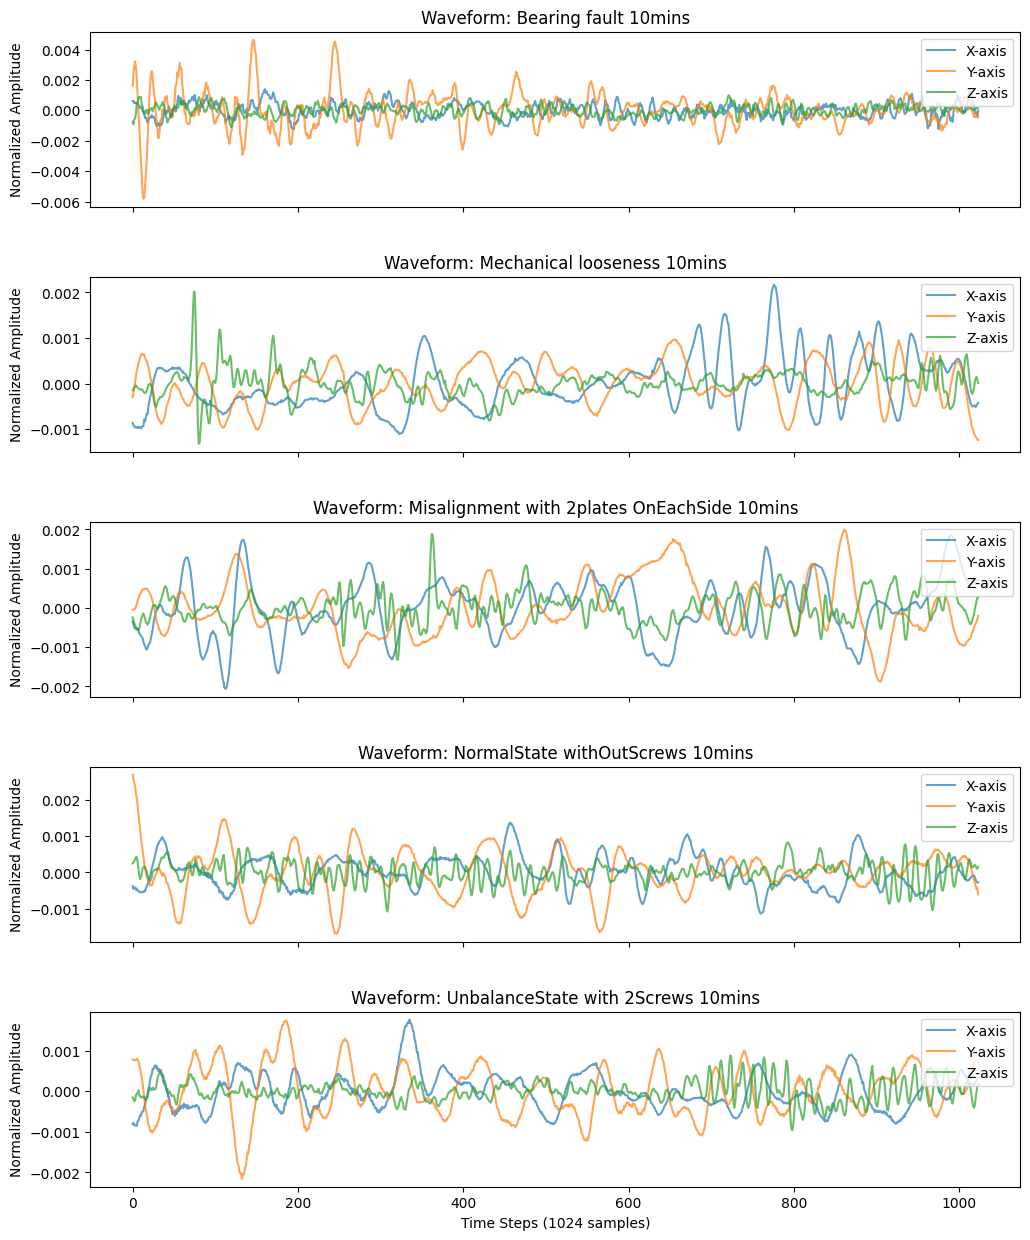

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique classes
unique_classes = np.unique(labels)

# Create a subplot for each class
fig, axes = plt.subplots(len(unique_classes), 1, figsize=(12, 15), sharex=True)
fig.subplots_adjust(hspace=0.4)

for i, cls in enumerate(unique_classes):
    # Find indices for the current class
    idx_list = np.where(labels == cls)[0]
    # Pick a random sample
    random_idx = np.random.choice(idx_list)

    # Extract the (3, 1024) tensor for this sample
    sample_tensor = tensors_normalized[random_idx]

    # Plot X, Y, and Z channels
    axes[i].plot(sample_tensor[0], label='X-axis', alpha=0.7)
    axes[i].plot(sample_tensor[1], label='Y-axis', alpha=0.7)
    axes[i].plot(sample_tensor[2], label='Z-axis', alpha=0.7)

    axes[i].set_title(f"Waveform: {cls}")
    axes[i].set_ylabel("Normalized Amplitude")
    axes[i].legend(loc='upper right')

axes[-1].set_xlabel("Time Steps (1024 samples)")
plt.show()


### Phase 2, Step 2: Sanity-Check FFT
Even though the CNN will learn from the time-domain waveform, it's good practice to check the frequency domain. We use `np.fft.rfft` to compute the real FFT and plot the magnitudes. With a motor running at 2000 RPM (~33.3 Hz) and a 50 kHz sampling rate, we should see characteristic frequency peaks based on the fault.

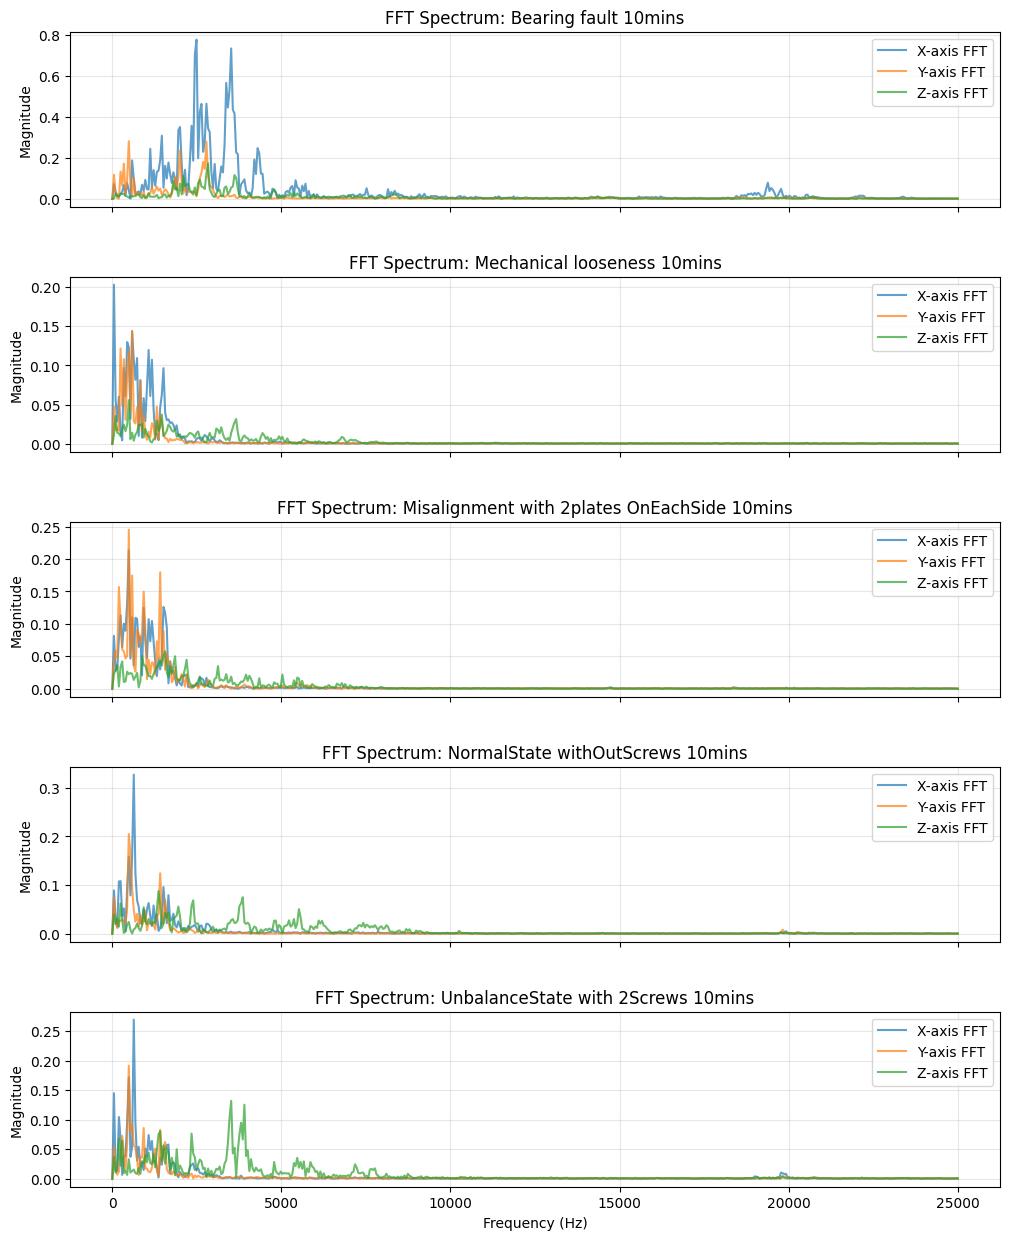

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters based on your plan
Fs = 50000.0  # 50 kHz sampling rate
N = 1024      # Number of samples per window

# Generate frequency axis (from 0 to Nyquist frequency, which is Fs/2)
freqs = np.fft.rfftfreq(N, d=1/Fs)

unique_classes = np.unique(labels)
fig, axes = plt.subplots(len(unique_classes), 1, figsize=(12, 15), sharex=True)
fig.subplots_adjust(hspace=0.4)

for i, cls in enumerate(unique_classes):
    # Pick a random sample from this class
    idx_list = np.where(labels == cls)[0]
    random_idx = np.random.choice(idx_list)

    # Extract X, Y, Z arrays for this sample
    sample_x = tensors_normalized[random_idx, 0, :]
    sample_y = tensors_normalized[random_idx, 1, :]
    sample_z = tensors_normalized[random_idx, 2, :]

    # Compute the FFT magnitude for each axis
    fft_x = np.abs(np.fft.rfft(sample_x))
    fft_y = np.abs(np.fft.rfft(sample_y))
    fft_z = np.abs(np.fft.rfft(sample_z))

    # Plot
    axes[i].plot(freqs, fft_x, label='X-axis FFT', alpha=0.7)
    axes[i].plot(freqs, fft_y, label='Y-axis FFT', alpha=0.7)
    axes[i].plot(freqs, fft_z, label='Z-axis FFT', alpha=0.7)

    axes[i].set_title(f"FFT Spectrum: {cls}")
    axes[i].set_ylabel("Magnitude")
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Frequency (Hz)")
plt.show()


### Phase 2, Step 3: Class Balance Check
We will count the aligned `(3, 1024)` windows for each state to see if our dataset is balanced or if we need to address any severe class imbalances before training the model.

Class Balance Check:
Bearing fault 10mins: 516 samples
Mechanical looseness 10mins: 273 samples
Misalignment with 2plates OnEachSide 10mins: 794 samples
NormalState withOutScrews 10mins: 778 samples
UnbalanceState with 2Screws 10mins: 729 samples


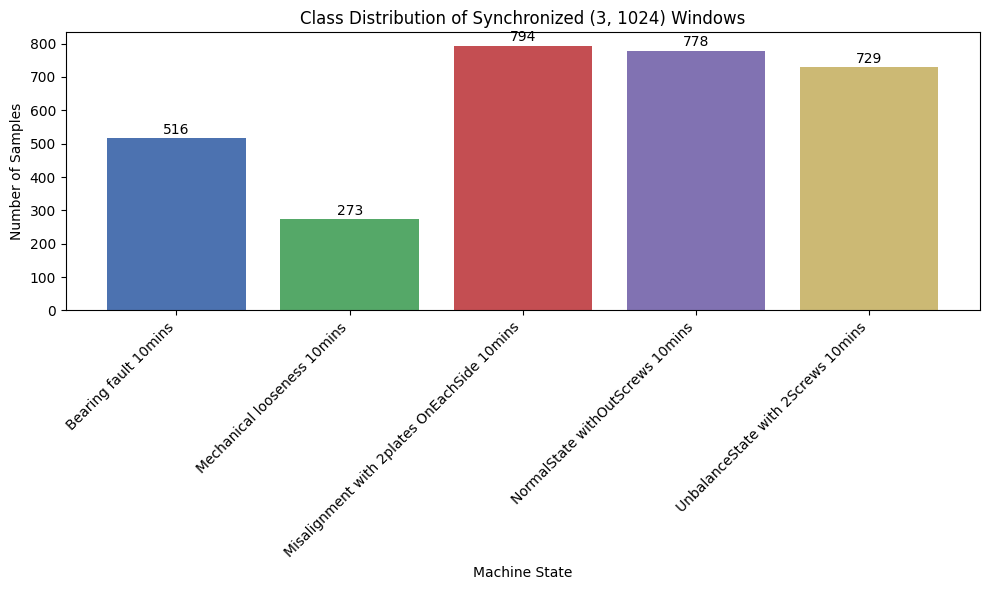

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Count the occurrences of each class
classes, counts = np.unique(labels, return_counts=True)

# Print the exact counts
print("Class Balance Check:")
for cls, count in zip(classes, counts):
    print(f"{cls}: {count} samples")

# Plot the distribution
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, counts, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'])
plt.title("Class Distribution of Synchronized (3, 1024) Windows")
plt.xlabel("Machine State")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha='right')

# Add count labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.tight_layout()
plt.show()


### Phase 3: The Train/Validation/Test Split
We split the dataset into three distinct vaults (70% Train, 15% Validation, 15% Test). We use `LabelEncoder` to translate string states into integers, and `stratify` to ensure an equal percentage of all five classes ends up in each split.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels to integers (0 to 4)
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)

# Print the mapping so we know which number corresponds to which state
print("Label Mapping:")
for i, class_name in enumerate(encoder.classes_):
    print(f"{i} -> {class_name}")

# First split: 70% Train, 30% Temp (which will be split into Val and Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    tensors_normalized,
    encoded_labels,
    test_size=0.30,
    random_state=42,
    stratify=encoded_labels
)

# Second split: 50% of Temp to Validation (15% of total), 50% of Temp to Test (15% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\n--- Data Splits ---")
print(f"Training set:   X={X_train.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape}")


Label Mapping:
0 -> Bearing fault 10mins
1 -> Mechanical looseness 10mins
2 -> Misalignment with 2plates OnEachSide 10mins
3 -> NormalState withOutScrews 10mins
4 -> UnbalanceState with 2Screws 10mins

--- Data Splits ---
Training set:   X=(2163, 3, 1024), y=(2163,)
Validation set: X=(463, 3, 1024), y=(463,)
Test set:       X=(464, 3, 1024), y=(464,)


### Phase 4: The 1D-CNN Architecture (Modeling)
We design a custom deep learning architecture tailored for our acoustic/vibration data. We transpose the data to `(samples, 1024, 3)` for Keras compatibility, apply Conv1D filters, pool them, and classify them through a dense Softmax head.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
import numpy as np

# Keras Conv1D expects inputs in the shape (batch_size, sequence_length, channels)
# Currently our shape is (samples, 3, 1024). We need to transpose it to (samples, 1024, 3)
X_train_k = np.transpose(X_train, (0, 2, 1))
X_val_k   = np.transpose(X_val, (0, 2, 1))
X_test_k  = np.transpose(X_test, (0, 2, 1))

print(f"Reshaped for Keras - Training set: {X_train_k.shape}\n")

# Define the 1D-CNN Architecture
model = Sequential([
    # Block 1: High-frequency filter (larger kernel size to catch rapid acoustic spikes)
    Conv1D(filters=32, kernel_size=16, activation='relu', input_shape=(1024, 3)),
    MaxPooling1D(pool_size=4),

    # Block 2: Mid-frequency filter
    Conv1D(filters=64, kernel_size=8, activation='relu'),
    MaxPooling1D(pool_size=4),

    # Block 3: Low-frequency filter (capturing slower patterns like unbalance)
    Conv1D(filters=128, kernel_size=4, activation='relu'),
    MaxPooling1D(pool_size=4),

    # Flatten spatial data to 1D vector
    Flatten(),

    # Fully connected dense layer for classification
    Dense(64, activation='relu'),
    Dropout(0.5),  # Prevent memorization/overfitting

    # Output layer: 5 nodes for 5 classes, using Softmax for probabilities
    Dense(5, activation='softmax')
])


Reshaped for Keras - Training set: (2163, 1024, 3)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model
# Since our labels are integers (0 to 4), we use 'sparse_categorical_crossentropy'
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display the architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1009, 32)       │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 252, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 245, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 61, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 58, 128)        │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       114,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,989 (648.39 KB)

 Trainable params: 165,989 (648.39 KB)

 Non-trainable params: 0 (0.00 B)

### Phase 4, Step 2: Training the Model
We pass the training data through the network. We use `EarlyStopping` to halt training if the validation loss stops improving, ensuring we don't overfit.

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.2432 - loss: 1.6834 - val_accuracy: 0.2570 - val_loss: 1.5631
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.2423 - loss: 1.5604 - val_accuracy: 0.2570 - val_loss: 1.5567
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.2552 - loss: 1.5579 - val_accuracy: 0.2505 - val_loss: 1.5513
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.2501 - loss: 1.5601 - val_accuracy: 0.2570 - val_loss: 1.5534
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.2469 - loss: 1.5557 - val_accuracy: 0.2570 - val_loss: 1.5481
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.2547 - loss: 1.5540 - val_accuracy: 0.2570 - val_loss: 1.5494
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.2381 - loss: 1.5544 - val_accuracy: 0.2570 - val_loss: 1.5481
Epoch 8/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.2566 - loss: 1.5526 - val_accuracy: 0.2570 - v

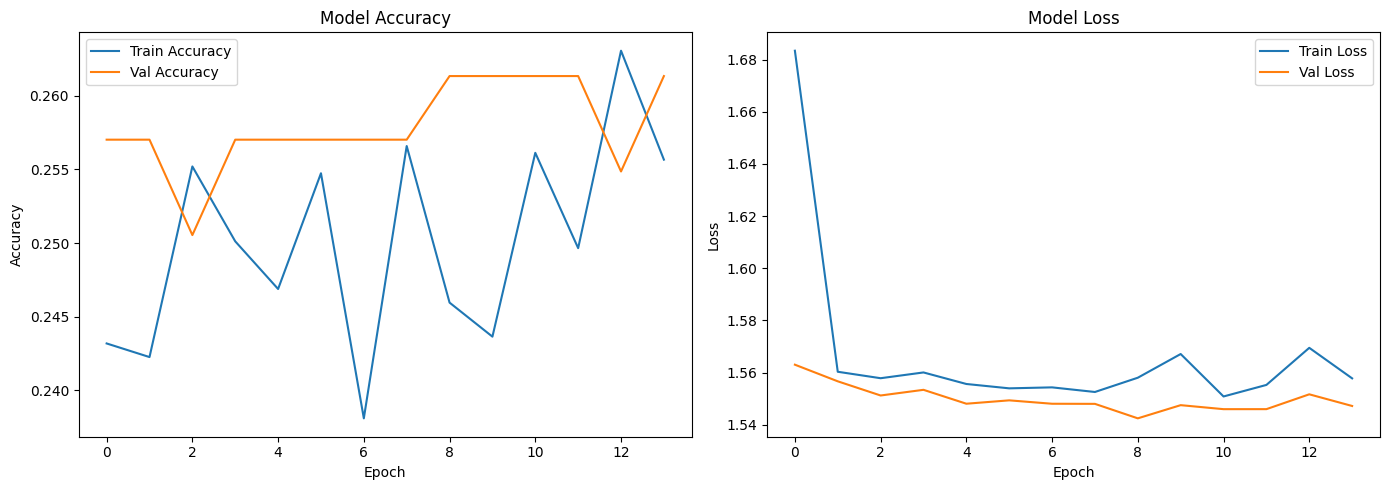

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,  # Wait 5 epochs before stopping if no improvement
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train_k,
    y_train,
    epochs=30,  # Maximum number of epochs
    batch_size=32,
    validation_data=(X_val_k, y_val),
    callbacks=[early_stop]
)

# Plot the training and validation accuracy/loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()


### Phase 4, Step 3: Model Evaluation
We evaluate the model's performance on the completely unseen Test set. A classification report is also generated to provide insights into precision, recall, and f1-score for each specific class.

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_k, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

# Get class predictions
y_pred_probs = model.predict(X_test_k)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Print the detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=encoder.classes_, zero_division=0))


Test Loss: 1.5577
Test Accuracy: 0.2608

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Classification Report:
                                             precision    recall  f1-score   support

                       Bearing fault 10mins       0.00      0.00      0.00        77
                Mechanical looseness 10mins       1.00      0.05      0.09        41
Misalignment with 2plates OnEachSide 10mins       0.26      1.00      0.41       119
           NormalState withOutScrews 10mins       0.00      0.00      0.00       117
         UnbalanceState with 2Screws 10mins       0.00      0.00      0.00       110

                                   accuracy                           0.26       464
                                  macro avg       0.25      0.21      0.10       464
                               weighted avg       0.15      0.26      0.11       464



### Phase 5: Optimization (Frequency Domain)
Here we convert our `(samples, 1024, 3)` time-domain tensors into `(samples, 513, 3)` frequency-domain tensors using `np.fft.rfft`.

In [ ]:
import numpy as np

# Compute the magnitude of the Real FFT along the sequence axis (axis=1)
X_train_fft = np.abs(np.fft.rfft(X_train_k, axis=1))
X_val_fft   = np.abs(np.fft.rfft(X_val_k, axis=1))
X_test_fft  = np.abs(np.fft.rfft(X_test_k, axis=1))

# FFT magnitudes can have massive spikes. We use log1p (log(1+x)) to compress the scale
X_train_fft = np.log1p(X_train_fft)
X_val_fft   = np.log1p(X_val_fft)
X_test_fft  = np.log1p(X_test_fft)

print(f"Original Time-Domain Shape: {X_train_k.shape}")
print(f"New Frequency-Domain Shape: {X_train_fft.shape}")


Original Time-Domain Shape: (2163, 1024, 3)
New Frequency-Domain Shape: (2163, 513, 3)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

# The number of frequency bins is now 513
freq_bins = X_train_fft.shape[1]
channels = X_train_fft.shape[2]

fft_model = Sequential([
    # Block 1
    Conv1D(filters=32, kernel_size=8, activation='relu', input_shape=(freq_bins, channels)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # Block 2
    Conv1D(filters=64, kernel_size=4, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # Block 3
    Conv1D(filters=128, kernel_size=4, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

fft_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
fft_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 506, 32)        │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 506, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 253, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 250, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 250, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 122, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 122, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 61, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7808)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       499,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,949 (2.07 MB)

 Trainable params: 542,501 (2.07 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.6070 - loss: 1.6297 - val_accuracy: 0.2333 - val_loss: 1.6593
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.7074 - loss: 0.6800 - val_accuracy: 0.0907 - val_loss: 2.0790
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.7411 - loss: 0.4825 - val_accuracy: 0.2613 - val_loss: 1.5992
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.7369 - loss: 0.4348 - val_accuracy: 0.3153 - val_loss: 1.6076
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.7434 - loss: 0.4930 - val_accuracy: 0.2376 - val_loss: 2.1437
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.7684 - loss: 0.4675 - val_accuracy: 0.1728 - val_loss: 2.0004
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.7628 - loss: 0.4025 - val_accuracy: 0.3067 - val_loss: 1.7686
Epoch 8/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7651 - loss: 0.3965 - val_accuracy: 0.6868 - v

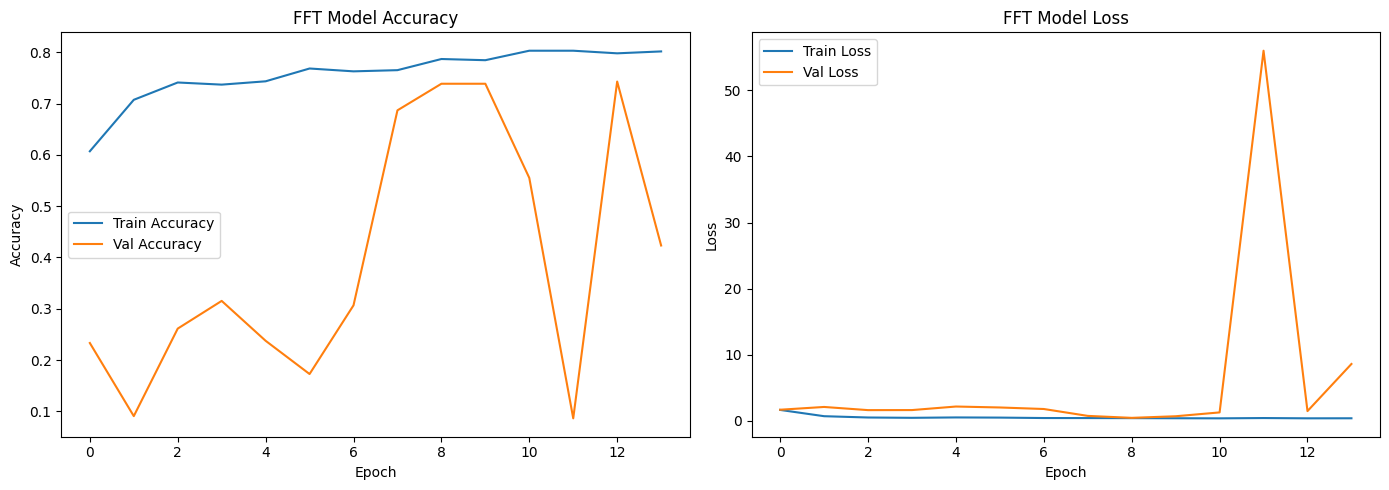

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Early stopping
early_stop_fft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history_fft = fft_model.fit(
    X_train_fft, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_fft, y_val),
    callbacks=[early_stop_fft]
)

# Plot the training and validation accuracy/loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_fft.history['accuracy'], label='Train Accuracy')
ax1.plot(history_fft.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('FFT Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history_fft.history['loss'], label='Train Loss')
ax2.plot(history_fft.history['val_loss'], label='Val Loss')
ax2.set_title('FFT Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()


### Phase 5, Step 2: Evaluating the Optimized Model
Let's see if our frequency-domain approach solved the 'model collapse' issue. We will evaluate the `fft_model` on our unseen test dataset and generate a new Classification Report.

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluate the FFT model
fft_test_loss, fft_test_accuracy = fft_model.evaluate(X_test_fft, y_test, verbose=0)
print(f"FFT Model Test Loss: {fft_test_loss:.4f}")
print(f"FFT Model Test Accuracy: {fft_test_accuracy:.4f}\n")

# Get class predictions for the FFT model
y_pred_probs_fft = fft_model.predict(X_test_fft)
y_pred_classes_fft = np.argmax(y_pred_probs_fft, axis=1)

# Print the detailed classification report
print("FFT Model Classification Report:")
print(classification_report(y_test, y_pred_classes_fft, target_names=encoder.classes_, zero_division=0))


FFT Model Test Loss: 0.4021
FFT Model Test Accuracy: 0.7586

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
FFT Model Classification Report:
                                             precision    recall  f1-score   support

                       Bearing fault 10mins       1.00      0.99      0.99        77
                Mechanical looseness 10mins       0.97      0.95      0.96        41
Misalignment with 2plates OnEachSide 10mins       1.00      0.99      1.00       119
           NormalState withOutScrews 10mins       0.77      0.09      0.15       117
         UnbalanceState with 2Screws 10mins       0.50      0.99      0.67       110

                                   accuracy                           0.76       464
                                  macro avg       0.85      0.80      0.75       464
                               weighted avg       0.82      0.76      0.70       464



### Phase 5 Alternative: Advanced 1D-CNN Architecture
Instead of manual feature extraction, we upgrade our neural network. We add `BatchNormalization` to stabilize learning, use `padding='same'` to preserve spatial dimensions, replace `Flatten` with `GlobalAveragePooling1D` to dramatically reduce overfitting, and use a slower learning rate.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

tuned_model = Sequential([
    # Block 1: Initial feature extraction
    Conv1D(filters=64, kernel_size=7, padding='same', input_shape=(1024, 3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    # Block 2: Deeper features
    Conv1D(filters=128, kernel_size=5, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    # Block 3: High-level representation
    Conv1D(filters=256, kernel_size=3, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    # Global Average Pooling replaces Flatten to reduce parameter count and overfitting
    GlobalAveragePooling1D(),

    # Classification head
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

# Compile with a slightly lower learning rate to avoid jumping into local minima (model collapse)
optimizer = Adam(learning_rate=0.0005)
tuned_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

tuned_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 1024, 64)       │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 512, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 256, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,389 (689.02 KB)

 Trainable params: 175,493 (685.52 KB)

 Non-trainable params: 896 (3.50 KB)

Training Tuned 1D-CNN on Time-Domain Data...
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 23s 311ms/step - accuracy: 0.4332 - loss: 1.2875 - val_accuracy: 0.2289 - val_loss: 1.6015
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 307ms/step - accuracy: 0.5141 - loss: 1.0836 - val_accuracy: 0.2570 - val_loss: 1.5826
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.5442 - loss: 1.0080 - val_accuracy: 0.2613 - val_loss: 1.5646
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 292ms/step - accuracy: 0.5691 - loss: 0.9703 - val_accuracy: 0.2635 - val_loss: 1.5767
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 295ms/step - accuracy: 0.5534 - loss: 0.9380 - val_accuracy: 0.1706 - val_loss: 1.6439
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 263ms/step - accuracy: 0.5830 - loss: 0.9334 - val_accuracy: 0.1685 - val_loss: 2.0043
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 22s 279ms/step - accuracy: 0.5978 - loss: 0.9127 - val_accuracy: 0.1706 - val_loss: 2.3800
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 284ms/step

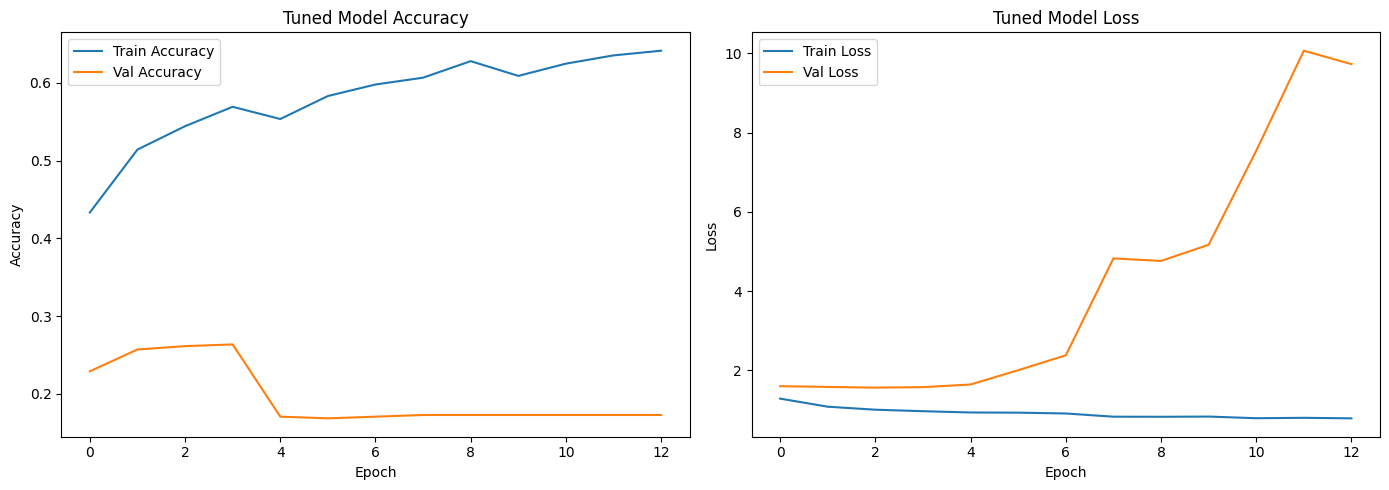

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Slightly longer patience since a lower learning rate takes more epochs to converge
early_stop_tuned = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Tuned 1D-CNN on Time-Domain Data...")
history_tuned = tuned_model.fit(
    X_train_k, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_k, y_val),
    callbacks=[early_stop_tuned]
)

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_tuned.history['accuracy'], label='Train Accuracy')
ax1.plot(history_tuned.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Tuned Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history_tuned.history['loss'], label='Train Loss')
ax2.plot(history_tuned.history['val_loss'], label='Val Loss')
ax2.set_title('Tuned Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()


### Phase 5 Alternative: Tuned 1D-CNN on FFT Data
Combining the advanced network architecture (Batch Normalization, Global Average Pooling) with the frequency-domain (FFT) data to prevent overfitting while extracting clean frequency signatures.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

# The number of frequency bins is 513
freq_bins = X_train_fft.shape[1]
channels = X_train_fft.shape[2]

tuned_fft_model = Sequential([
    # Block 1
    Conv1D(filters=64, kernel_size=7, padding='same', input_shape=(freq_bins, channels)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    # Block 2
    Conv1D(filters=128, kernel_size=5, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    # Block 3
    Conv1D(filters=256, kernel_size=3, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    # Global Average Pooling to reduce dimensions and prevent overfitting
    GlobalAveragePooling1D(),

    # Classification head
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

# Compile with lower learning rate
optimizer = Adam(learning_rate=0.0005)
tuned_fft_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

tuned_fft_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 513, 64)        │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 513, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 513, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 256, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 128, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,389 (689.02 KB)

 Trainable params: 175,493 (685.52 KB)

 Non-trainable params: 896 (3.50 KB)

Training Tuned 1D-CNN on FFT Data...
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - accuracy: 0.4184 - loss: 1.4309 - val_accuracy: 0.2549 - val_loss: 1.5819
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.5002 - loss: 1.2322 - val_accuracy: 0.1641 - val_loss: 1.6773
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.5363 - loss: 1.1294 - val_accuracy: 0.1663 - val_loss: 2.0120
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.5742 - loss: 1.0483 - val_accuracy: 0.1663 - val_loss: 2.6839
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.6181 - loss: 0.9125 - val_accuracy: 0.1663 - val_loss: 3.0292
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.6366 - loss: 0.8565 - val_accuracy: 0.1663 - val_loss: 4.5624
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - accuracy: 0.6556 - loss: 0.7835 - val_accuracy: 0.1663 - val_loss: 5.0154
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy

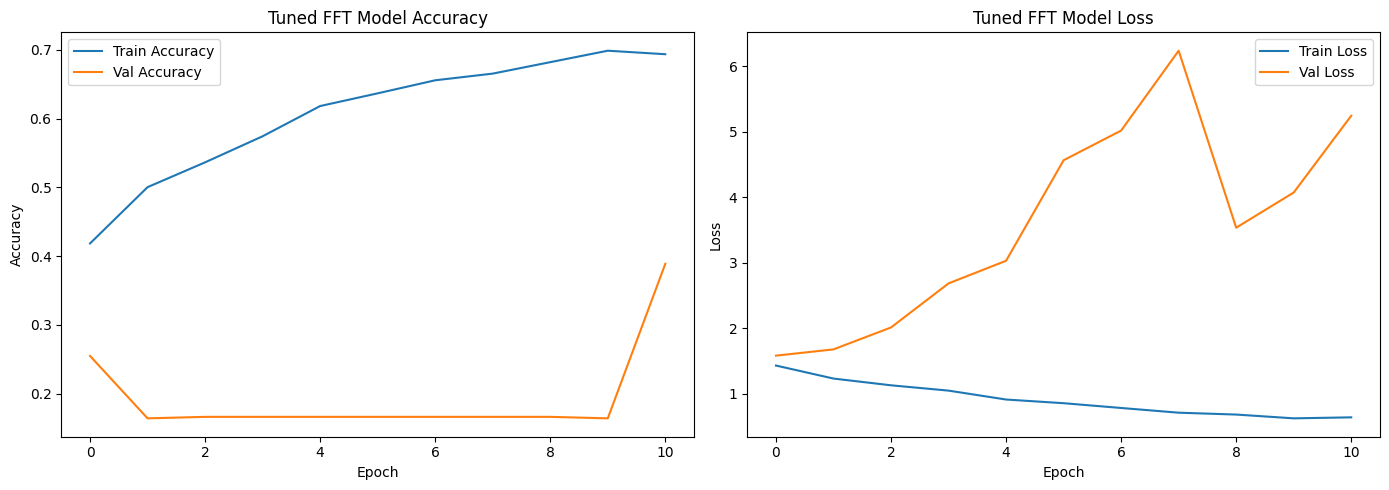

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

early_stop_tuned_fft = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Tuned 1D-CNN on FFT Data...")
history_tuned_fft = tuned_fft_model.fit(
    X_train_fft, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_fft, y_val),
    callbacks=[early_stop_tuned_fft]
)

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_tuned_fft.history['accuracy'], label='Train Accuracy')
ax1.plot(history_tuned_fft.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Tuned FFT Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history_tuned_fft.history['loss'], label='Train Loss')
ax2.plot(history_tuned_fft.history['val_loss'], label='Val Loss')
ax2.set_title('Tuned FFT Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()


### Phase 5 Alternative: Evaluate the Tuned FFT Model
Let's test our advanced 1D-CNN architecture trained on frequency-domain data against the unseen test set.

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluate the Tuned FFT model
tuned_fft_test_loss, tuned_fft_test_accuracy = tuned_fft_model.evaluate(X_test_fft, y_test, verbose=0)
print(f"Tuned FFT Model Test Loss: {tuned_fft_test_loss:.4f}")
print(f"Tuned FFT Model Test Accuracy: {tuned_fft_test_accuracy:.4f}\n")

# Get class predictions
y_pred_probs_tuned_fft = tuned_fft_model.predict(X_test_fft)
y_pred_classes_tuned_fft = np.argmax(y_pred_probs_tuned_fft, axis=1)

# Print the detailed classification report
print("Tuned FFT Model Classification Report:")
print(classification_report(y_test, y_pred_classes_tuned_fft, target_names=encoder.classes_, zero_division=0))


Tuned FFT Model Test Loss: 1.5719
Tuned FFT Model Test Accuracy: 0.2565

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
Tuned FFT Model Classification Report:
                                             precision    recall  f1-score   support

                       Bearing fault 10mins       0.00      0.00      0.00        77
                Mechanical looseness 10mins       1.00      0.05      0.09        41
Misalignment with 2plates OnEachSide 10mins       0.00      0.00      0.00       119
           NormalState withOutScrews 10mins       0.25      1.00      0.41       117
         UnbalanceState with 2Screws 10mins       0.00      0.00      0.00       110

                                   accuracy                           0.26       464
                                  macro avg       0.25      0.21      0.10       464
                               weighted avg       0.15      0.26      0.11       464



### Phase 6: Error Analysis (Confusion Matrix)
Let's visualize exactly where our Tuned FFT model is making mistakes, specifically to investigate why the 'Normal state' recall is so low.

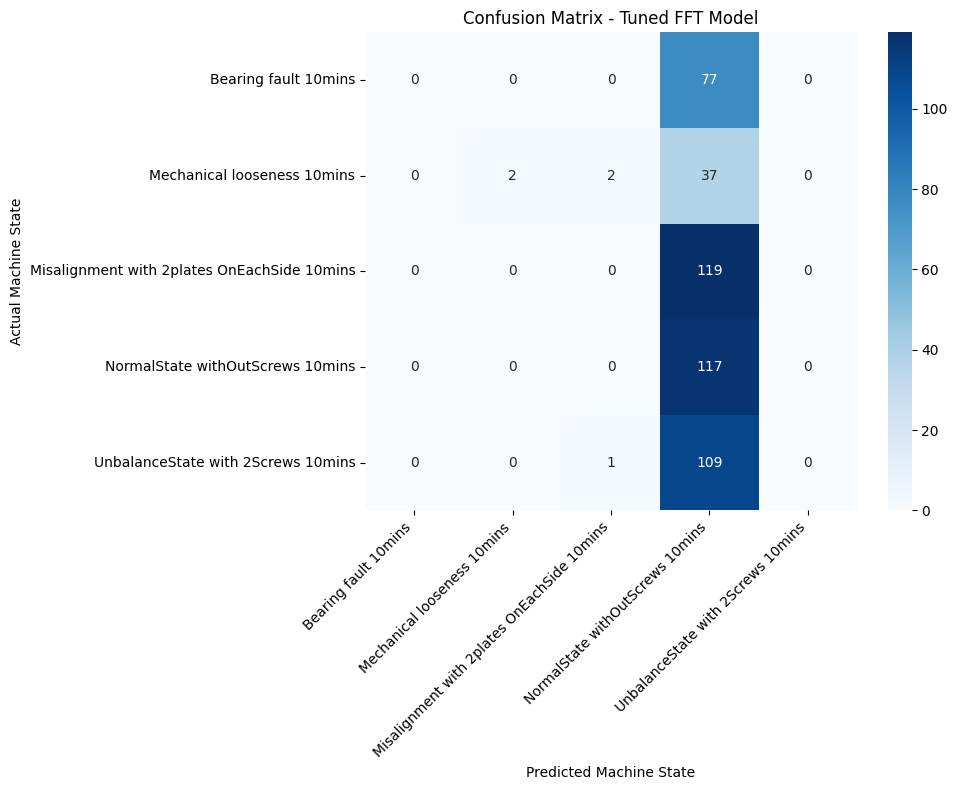

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes_tuned_fft)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.title('Confusion Matrix - Tuned FFT Model')
plt.ylabel('Actual Machine State')
plt.xlabel('Predicted Machine State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Phase 7: Save Best Model & Class Weight Optimization
First, we save the `tuned_fft_model`. Then, we calculate class weights and retrain the architecture to see if we can force the network to properly distinguish the Normal state from the Unbalance state.

In [ ]:
# Save the current best performing model
tuned_fft_model.save('tuned_fft_vibration_model.keras')
print("Model saved successfully as 'tuned_fft_vibration_model.keras'")

Model saved successfully as 'tuned_fft_vibration_model.keras'


Computed Class Weights:
Class 0 (Bearing fault 10mins): 1.1983
Class 1 (Mechanical looseness 10mins): 2.2649
Class 2 (Misalignment with 2plates OnEachSide 10mins): 0.7781
Class 3 (NormalState withOutScrews 10mins): 0.7938
Class 4 (UnbalanceState with 2Screws 10mins): 0.8482


Training Tuned 1D-CNN with Class Weights...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 138ms/step - accuracy: 0.3551 - loss: 1.4440 - val_accuracy: 0.1641 - val_loss: 1.6071
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.4642 - loss: 1.2519 - val_accuracy: 0.1663 - val_loss: 1.7602
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.4901 - loss: 1.1482 - val_accuracy: 0.1663 - val_loss: 2.6029
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 0.5169 - loss: 1.1253 - val_accuracy: 0.1663 - val_loss: 3.8902
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.5349 - loss: 1.0529 - val_accuracy: 0.1663 - val_loss: 4.3550
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - accuracy: 0.5908 - loss: 0.9616 - val_accuracy: 0.1641 - val_loss: 5.0367
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - accuracy: 0.6375 - loss: 0.8510 - val_accuracy: 0.1641 - val_loss: 5.3416
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.6117 - loss: 0.8292 - val_accuracy: 0.1663 -

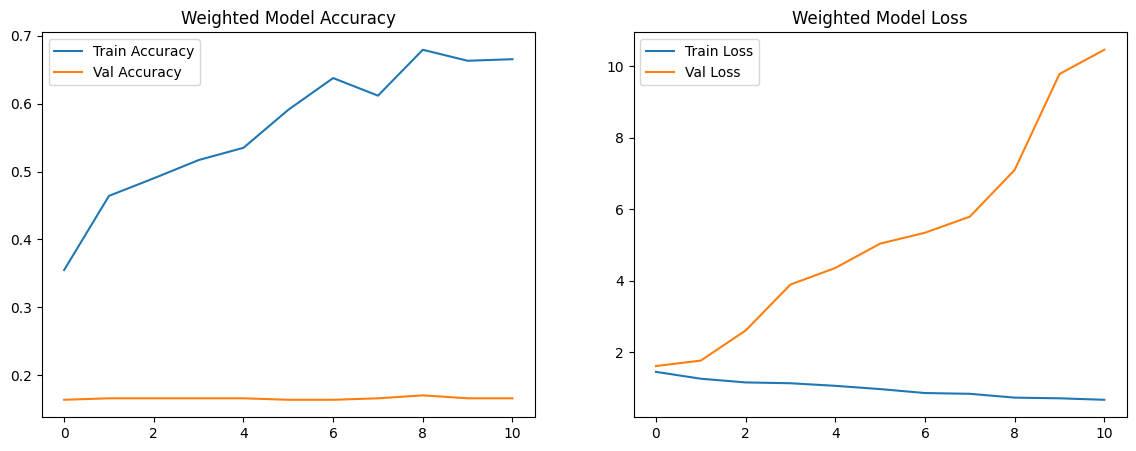

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate class weights
unique_classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train)
class_weight_dict = dict(zip(unique_classes, weights))

print("Computed Class Weights:")
for cls, weight in class_weight_dict.items():
    print(f"Class {cls} ({encoder.inverse_transform([cls])[0]}): {weight:.4f}")
print("\n")

# 2. Re-initialize the model to train from scratch
weighted_fft_model = Sequential([
    Conv1D(filters=64, kernel_size=7, padding='same', input_shape=(freq_bins, channels)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=5, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=256, kernel_size=3, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

optimizer = Adam(learning_rate=0.0005)
weighted_fft_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Train with class weights
early_stop_weighted = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Tuned 1D-CNN with Class Weights...")
history_weighted = weighted_fft_model.fit(
    X_train_fft, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_fft, y_val),
    callbacks=[early_stop_weighted],
    class_weight=class_weight_dict  # <-- The crucial addition
)

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_weighted.history['accuracy'], label='Train Accuracy')
ax1.plot(history_weighted.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Weighted Model Accuracy')
ax1.legend()

ax2.plot(history_weighted.history['loss'], label='Train Loss')
ax2.plot(history_weighted.history['val_loss'], label='Val Loss')
ax2.set_title('Weighted Model Loss')
ax2.legend()
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Evaluate the Weighted FFT model
weighted_test_loss, weighted_test_accuracy = weighted_fft_model.evaluate(X_test_fft, y_test, verbose=0)
print(f"Weighted FFT Model Test Accuracy: {weighted_test_accuracy:.4f}\n")

# Get class predictions
y_pred_probs_weighted = weighted_fft_model.predict(X_test_fft)
y_pred_classes_weighted = np.argmax(y_pred_probs_weighted, axis=1)

# Print the detailed classification report
print("Weighted FFT Model Classification Report:")
print(classification_report(y_test, y_pred_classes_weighted, target_names=encoder.classes_, zero_division=0))


Weighted FFT Model Test Accuracy: 0.1724

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
Weighted FFT Model Classification Report:
                                             precision    recall  f1-score   support

                       Bearing fault 10mins       0.17      0.99      0.28        77
                Mechanical looseness 10mins       0.80      0.10      0.17        41
Misalignment with 2plates OnEachSide 10mins       0.00      0.00      0.00       119
           NormalState withOutScrews 10mins       0.00      0.00      0.00       117
         UnbalanceState with 2Screws 10mins       0.00      0.00      0.00       110

                                   accuracy                           0.17       464
                                  macro avg       0.19      0.22      0.09       464
                               weighted avg       0.10      0.17      0.06       464

